<a href="https://colab.research.google.com/github/j19rajput-svg/MyProjects/blob/main/mecedesbenz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
train_data = pd.read_csv('train.csv')
print(train_data.head())

   ID       y  X0 X1  X2 X3 X4 X5 X6 X8  ...  X375  X376  X377  X378  X379  \
0   0  130.81   k  v  at  a  d  u  j  o  ...     0     0     1     0     0   
1   6   88.53   k  t  av  e  d  y  l  o  ...     1     0     0     0     0   
2   7   76.26  az  w   n  c  d  x  j  x  ...     0     0     0     0     0   
3   9   80.62  az  t   n  f  d  x  l  e  ...     0     0     0     0     0   
4  13   78.02  az  v   n  f  d  h  d  n  ...     0     0     0     0     0   

   X380  X382  X383  X384  X385  
0     0     0     0     0     0  
1     0     0     0     0     0  
2     0     1     0     0     0  
3     0     0     0     0     0  
4     0     0     0     0     0  

[5 rows x 378 columns]


In [ ]:
test_data = pd.read_csv('test.csv')
print(test_data.head())

   ID  X0 X1  X2 X3 X4 X5 X6 X8  X10  ...  X375  X376  X377  X378  X379  X380  \
0   1  az  v   n  f  d  t  a  w    0  ...     0     0     0     1     0     0   
1   2   t  b  ai  a  d  b  g  y    0  ...     0     0     1     0     0     0   
2   3  az  v  as  f  d  a  j  j    0  ...     0     0     0     1     0     0   
3   4  az  l   n  f  d  z  l  n    0  ...     0     0     0     1     0     0   
4   5   w  s  as  c  d  y  i  m    0  ...     1     0     0     0     0     0   

   X382  X383  X384  X385  
0     0     0     0     0  
1     0     0     0     0  
2     0     0     0     0  
3     0     0     0     0  
4     0     0     0     0  

[5 rows x 377 columns]


In [ ]:
print(train_data.shape)

(4209, 378)


In [ ]:
print(test_data.shape)

(4209, 377)


In [ ]:
for i in train_data.columns:
  data_type = train_data[i].dtype
  if data_type == 'object':
    print(i)

X0
X1
X2
X3
X4
X5
X6
X8


In [ ]:
variance=pow(train_data.drop(columns={'ID','y'}).select_dtypes(include=np.number).std(),2).to_dict()
null_count = 0
for key,value in variance.items():
    if(value==0):
           print('Name=',key)
           null_count=null_count+1
print('Number of columns which has zero variance',null_count)

Name= X11
Name= X93
Name= X107
Name= X233
Name= X235
Name= X268
Name= X289
Name= X290
Name= X293
Name= X297
Name= X330
Name= X347
Number of columns which has zero variance 12


In [ ]:
train_data=train_data.drop(columns={'X11','X93','X107','X233','X235','X268','X289','X290','X293','X297','X330','X347'})
train_data.head()

,ID,y,X0,X1,X2,X3,X4,X5,X6,X8,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,0,130.81,k,v,at,a,d,u,j,o,...,0,0,1,0,0,0,0,0,0,0
1,6,88.53,k,t,av,e,d,y,l,o,...,1,0,0,0,0,0,0,0,0,0
2,7,76.26,az,w,n,c,d,x,j,x,...,0,0,0,0,0,0,1,0,0,0
3,9,80.62,az,t,n,f,d,x,l,e,...,0,0,0,0,0,0,0,0,0,0
4,13,78.02,az,v,n,f,d,h,d,n,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train_data.shape

(4209, 366)

In [ ]:
train_data.isnull().sum().any()

np.False_

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder

In [ ]:
train_data_feature = train_data.drop(columns={'y','ID'})
train_data_target = train_data.y

In [ ]:
train_data_feature.head()

,X0,X1,X2,X3,X4,X5,X6,X8,X10,X12,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,k,v,at,a,d,u,j,o,0,0,...,0,0,1,0,0,0,0,0,0,0
1,k,t,av,e,d,y,l,o,0,0,...,1,0,0,0,0,0,0,0,0,0
2,az,w,n,c,d,x,j,x,0,0,...,0,0,0,0,0,0,1,0,0,0
3,az,t,n,f,d,x,l,e,0,0,...,0,0,0,0,0,0,0,0,0,0
4,az,v,n,f,d,h,d,n,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train_data_target.head()

,y
0,130.81
1,88.53
2,76.26
3,80.62
4,78.02


In [ ]:
print(train_data_feature.shape)

(4209, 364)


In [ ]:
print(train_data_target.shape)

(4209,)


In [ ]:
train_data_feature.describe(include='object')

,X0,X1,X2,X3,X4,X5,X6,X8
count,4209,4209,4209,4209,4209,4209,4209,4209
unique,47,27,44,7,4,29,12,25
top,z,aa,as,c,d,v,g,j
freq,360,833,1659,1942,4205,231,1042,277


In [ ]:
le=LabelEncoder()
train_data_feature['X0']=le.fit_transform(train_data_feature.X0)
train_data_feature['X1']=le.fit_transform(train_data_feature.X1)
train_data_feature['X2']=le.fit_transform(train_data_feature.X2)
train_data_feature['X3']=le.fit_transform(train_data_feature.X3)
train_data_feature['X4']=le.fit_transform(train_data_feature.X4)
train_data_feature['X5']=le.fit_transform(train_data_feature.X5)
train_data_feature['X6']=le.fit_transform(train_data_feature.X6)
train_data_feature['X8']=le.fit_transform(train_data_feature.X8)

In [ ]:
print(train_data_feature.shape)
print(train_data_target.shape)

(4209, 364)
(4209,)


In [ ]:
train_data_feature.head()

,X0,X1,X2,X3,X4,X5,X6,X8,X10,X12,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,32,23,17,0,3,24,9,14,0,0,...,0,0,1,0,0,0,0,0,0,0
1,32,21,19,4,3,28,11,14,0,0,...,1,0,0,0,0,0,0,0,0,0
2,20,24,34,2,3,27,9,23,0,0,...,0,0,0,0,0,0,1,0,0,0
3,20,21,34,5,3,27,11,4,0,0,...,0,0,0,0,0,0,0,0,0,0
4,20,23,34,5,3,12,3,13,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train_data_target.head()

,y
0,130.81
1,88.53
2,76.26
3,80.62
4,78.02


In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=.95)
pca.fit(train_data_feature,train_data_target)

PCA(n_components=0.95)

In [ ]:
train_data_feature_trans = pca.fit_transform(train_data_feature)
print(train_data_feature_trans.shape)

(4209, 6)


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
from math import sqrt

In [ ]:
train_x,test_x,train_y,test_y = train_test_split(train_data_feature_trans,train_data_target,test_size=0.30,random_state=42)
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

(2946, 6)
(2946,)
(1263, 6)
(1263,)


In [ ]:
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    colsample_bytree=0.3,
    learning_rate=0.1,
    max_depth=5,
    alpha=10,
    n_estimators=100
)

model = xgb_reg.fit(train_x, train_y)

pred_test = model.predict(test_x)

print("RMSE =", sqrt(mean_squared_error(test_y, pred_test)))

RMSE = 11.624274721080875


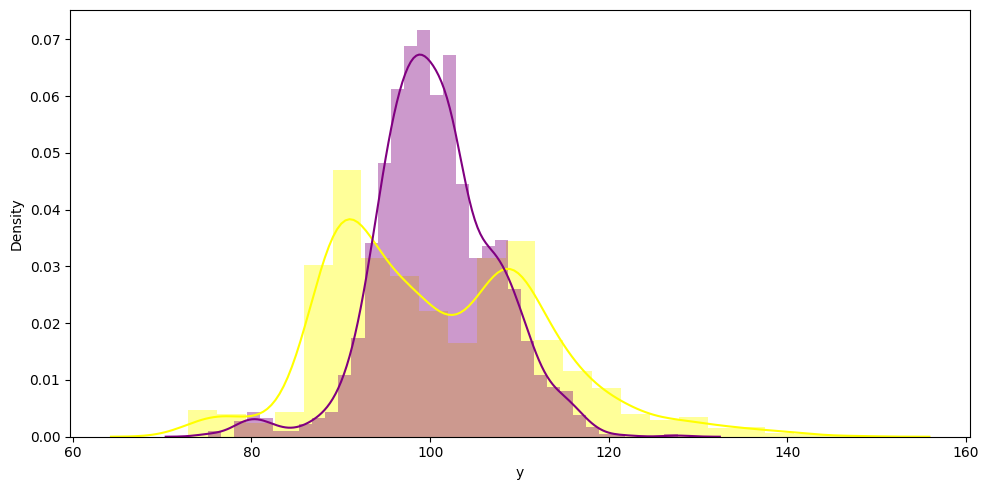

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
pred_test_y=model.predict(test_x)
plt.figure(figsize=(10,5))
sns.distplot(test_y[test_y<150],color="yellow",label="Actual value")
sns.distplot(pred_test_y[pred_test_y<150],color="purple",label="predicted value")
plt.tight_layout()

In [ ]:
dmatrix_train = xgb.DMatrix(
    data=train_data_feature_trans,
    label=train_data_target
)
params = {
    'objective': 'reg:squarederror',   # use 'reg:linear' only for old XGBoost versions
    'colsample_bytree': 0.3,
    'learning_rate': 0.1,
    'max_depth': 5,
    'alpha': 10,
    'eval_metric': 'rmse'
}
model_cv = xgb.cv(
    dtrain=dmatrix_train,
    params=params,
    nfold=3,
    num_boost_round=50,
    early_stopping_rounds=10,
    metrics="rmse",
    seed=123,
    as_pandas=True
)
print(model_cv.tail())

    train-rmse-mean  train-rmse-std  test-rmse-mean  test-rmse-std
45        10.226493        0.225874       10.994043       0.379300
46        10.197938        0.234130       10.981921       0.383791
47        10.177668        0.233994       10.970811       0.386602
48        10.155663        0.240898       10.959217       0.387072
49        10.145822        0.243690       10.962409       0.387332


In [ ]:
test_data=test_data.drop(columns={'X11','X93','X107','X233','X235','X268','X289','X290','X293','X297','X330','X347'})
test_data.head()

,ID,X0,X1,X2,X3,X4,X5,X6,X8,X10,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,1,az,v,n,f,d,t,a,w,0,...,0,0,0,1,0,0,0,0,0,0
1,2,t,b,ai,a,d,b,g,y,0,...,0,0,1,0,0,0,0,0,0,0
2,3,az,v,as,f,d,a,j,j,0,...,0,0,0,1,0,0,0,0,0,0
3,4,az,l,n,f,d,z,l,n,0,...,0,0,0,1,0,0,0,0,0,0
4,5,w,s,as,c,d,y,i,m,0,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
test_data.shape

(4209, 365)

In [ ]:
test_data.isnull().sum().any()

np.False_

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder

In [ ]:
test_data_feature=test_data.drop(columns={'ID'})
print(test_data_feature.shape)

(4209, 364)


In [ ]:
test_data_feature.head()

,X0,X1,X2,X3,X4,X5,X6,X8,X10,X12,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,az,v,n,f,d,t,a,w,0,0,...,0,0,0,1,0,0,0,0,0,0
1,t,b,ai,a,d,b,g,y,0,0,...,0,0,1,0,0,0,0,0,0,0
2,az,v,as,f,d,a,j,j,0,0,...,0,0,0,1,0,0,0,0,0,0
3,az,l,n,f,d,z,l,n,0,0,...,0,0,0,1,0,0,0,0,0,0
4,w,s,as,c,d,y,i,m,0,0,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
test_data_feature.describe(include='object')

,X0,X1,X2,X3,X4,X5,X6,X8
count,4209,4209,4209,4209,4209,4209,4209,4209
unique,49,27,45,7,4,32,12,25
top,ak,aa,as,c,d,v,g,e
freq,432,826,1658,1900,4203,246,1073,274


In [ ]:
le=LabelEncoder()
test_data_feature['X0']=le.fit_transform(test_data_feature.X0)
test_data_feature['X1']=le.fit_transform(test_data_feature.X1)
test_data_feature['X2']=le.fit_transform(test_data_feature.X2)
test_data_feature['X3']=le.fit_transform(test_data_feature.X3)
test_data_feature['X4']=le.fit_transform(test_data_feature.X4)
test_data_feature['X5']=le.fit_transform(test_data_feature.X5)
test_data_feature['X6']=le.fit_transform(test_data_feature.X6)
test_data_feature['X8']=le.fit_transform(test_data_feature.X8)


In [ ]:
test_data_feature.head()

,X0,X1,X2,X3,X4,X5,X6,X8,X10,X12,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,21,23,34,5,3,26,0,22,0,0,...,0,0,0,1,0,0,0,0,0,0
1,42,3,8,0,3,9,6,24,0,0,...,0,0,1,0,0,0,0,0,0,0
2,21,23,17,5,3,0,9,9,0,0,...,0,0,0,1,0,0,0,0,0,0
3,21,13,34,5,3,31,11,13,0,0,...,0,0,0,1,0,0,0,0,0,0
4,45,20,17,2,3,30,8,12,0,0,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
test_data_feature.shape

(4209, 364)

In [ ]:
test_data_feature.dtypes.value_counts()

,count
int64,364


In [ ]:
pca.fit(test_data_feature)

PCA(n_components=0.95)

In [ ]:
test_data_feature_trans=pca.fit_transform(test_data_feature)
print(test_data_feature_trans.shape)

(4209, 6)


In [ ]:
print(test_data_feature_trans)

[[-14.58336183  14.16672593  13.53857566   2.40835691  11.31942221
   -6.94220721]
 [ 15.25161267  -7.73675643  -7.45495068  -2.66203503  11.59379316
   -1.15940345]
 [-11.8564649   -1.68017324  -9.9896148   14.91886587  -1.08886021
    2.69130553]
 ...
 [ 13.44644008   3.2885825   -6.85236431  18.91025575  11.32365564
   -3.22410016]
 [-24.92612317  -4.89888683 -10.16941028  11.44337736   5.90178724
   -4.55323232]
 [ 15.38430989  -7.73425491 -15.4930104   -0.5595126    4.7793639
   -1.0829113 ]]


In [ ]:
test_pred=model.predict(test_data_feature_trans)
test_pred

array([ 91.49339 ,  95.82922 , 102.84926 , ...,  94.85359 , 111.85135 ,
       100.231575], dtype=float32)

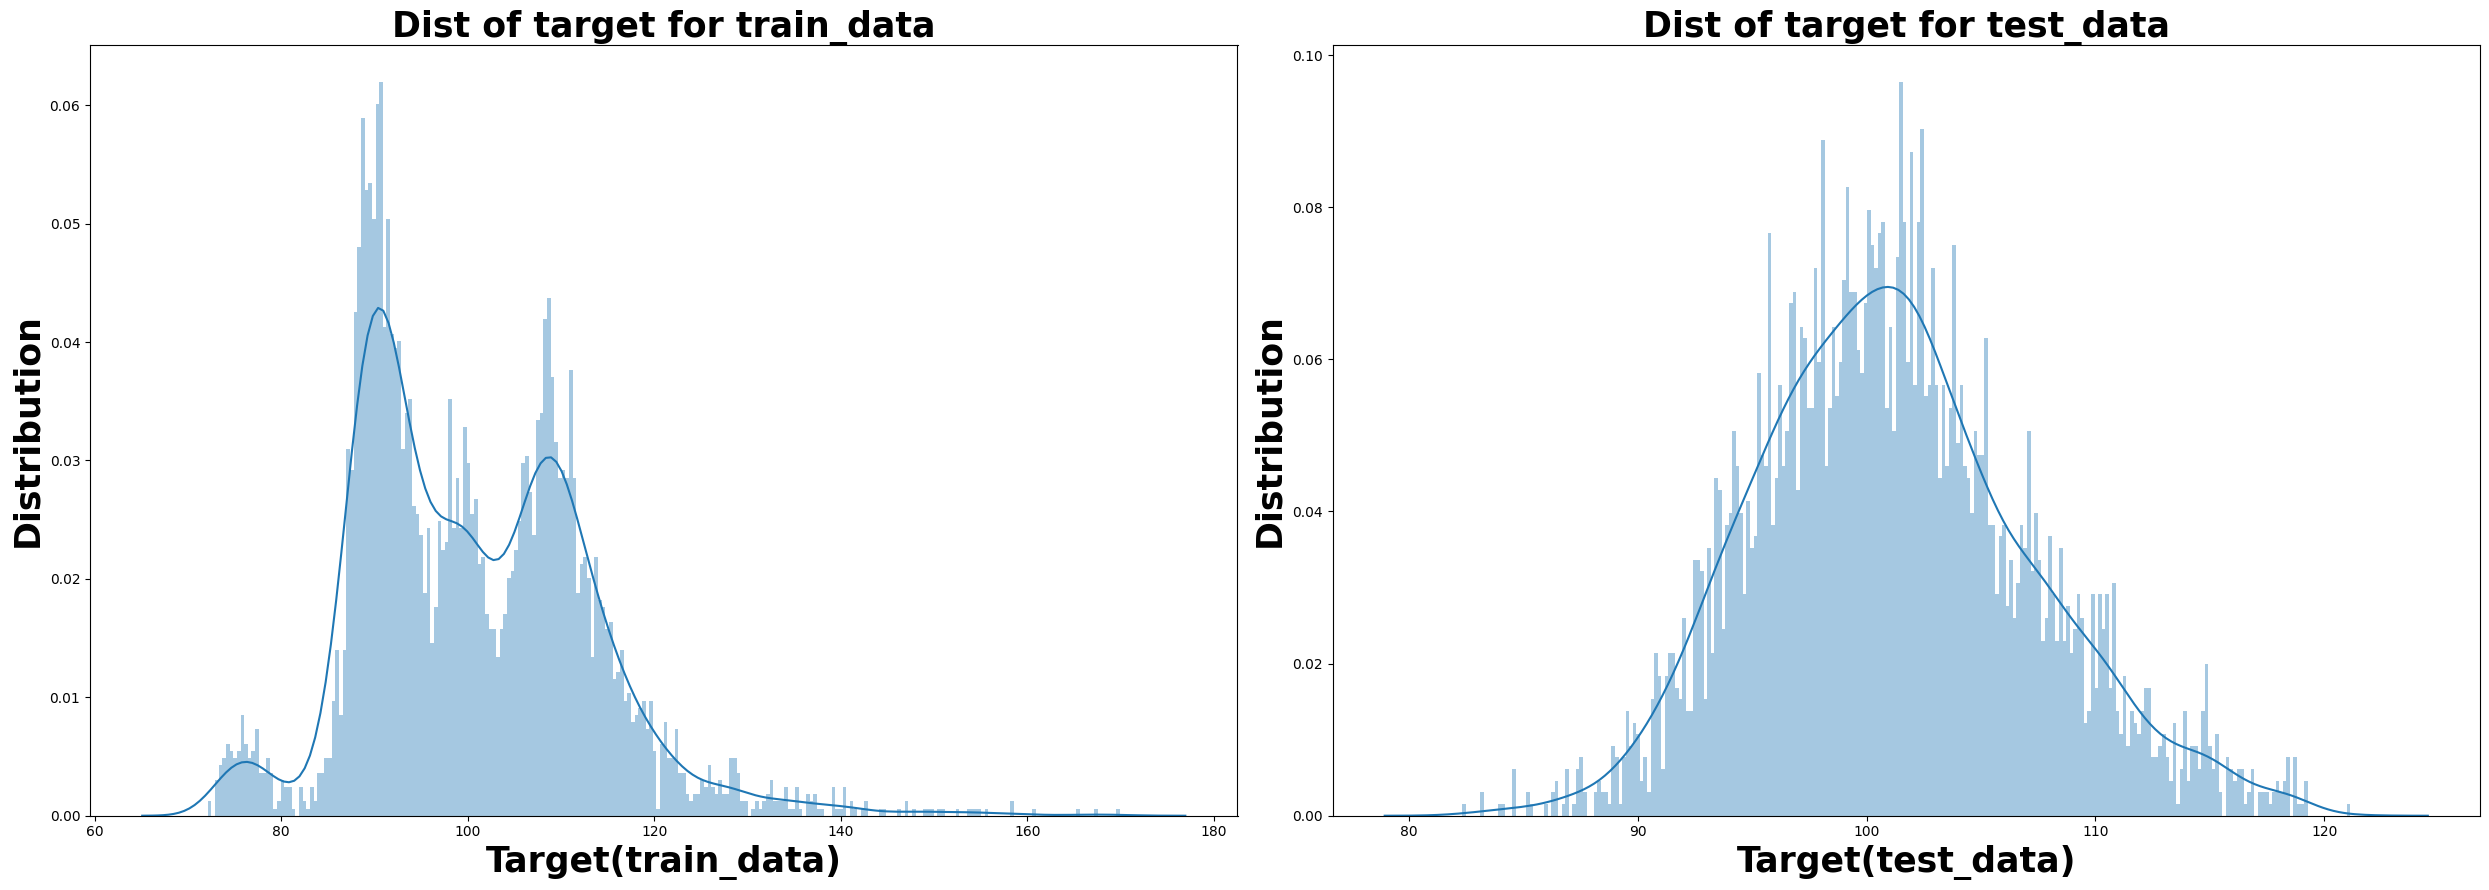

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(25,9))
train_plot=sns.distplot(train_data_target[train_data_target<250],bins=250,kde=True,ax=ax[0])
train_plot.set_xlabel('Target(train_data)',weight='bold',size=25)
train_plot.set_ylabel('Distribution',weight='bold',size=25)
train_plot.set_title('Dist of target for train_data',weight='bold',size=25)
test_plot=sns.distplot(test_pred[test_pred<250],bins=250,kde=True,ax=ax[1])
test_plot.set_xlabel('Target(test_data)',weight='bold',size=25)
test_plot.set_ylabel('Distribution',weight='bold',size=25)
test_plot.set_title('Dist of target for test_data',weight='bold',size=25)
plt.tight_layout()